In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r'C:\z_Learn\miraj_pandas\Deep Learning\NLP\data.csv')
df.head(4)

,sentence,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1


In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and stem
    # words = [stemmer.stem(word) for word in words if word not in stop_words]
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply to the dataframe
df["sentence"] = df["sentence"].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\I1000929\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
x = df['sentence']
y = df['label']
print(f"{x.iat[2]}  : {y.iat[1]}")

tasty texture nasty  : 0


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [6]:
print("shape of X_train: ",X_train.shape)
print("shape of X_test: ",X_test.shape)

print("shape of y_train: ",y_train.shape)
print("shape of y_test: ",y_test.shape)

shape of X_train:  (800,)
shape of X_test:  (200,)
shape of y_train:  (800,)
shape of y_test:  (200,)


### Vocabulary Created by `Tokenizer`

```text
food        -> 1
good        -> 2
service     -> 3
...
atmosphere  -> 1000
mediocre    -> 1001
overpriced  -> 1002
```
- `Keras Tokenizer` assigns indices based on word frequency.

### Convert Text to Sequence

```python
tokenizer.texts_to_sequences(["good food overpriced"])
```

**Output:**

```text
[2, 1]
```

**Explanation:**
- `food` → `1` ✅ (within the top `num_words`)
- `good` → `2` ✅ (within the top `num_words`)
- `overpriced` → `1002` ❌ (ignored because `num_words=1000` keeps only indices `< 1000`)
- Hence the final sequence is:

```text
[2, 1]
```

In [7]:
X_train

652    perfect sitdown family meal get together friends
679                              service slow attentive
465                  food outstanding prices reasonable
885                       two bites refused eat anymore
521                                      havent gone go
                             ...                       
306                                  never ever go back
808         lastly mozzarella sticks best thing ordered
262                     restaurant atmosphere exquisite
547                                    even hello right
429       nicest restaurant owners ive ever come across
Name: sentence, Length: 800, dtype: object

In [8]:
# we will use the Tokenizer class : create a word-to-index dictionary. In the word-to-index dictionary,
from tensorflow.keras.preprocessing.text import Tokenizer


tokenizer = Tokenizer(num_words=500,lower=True) 
tokenizer.fit_on_texts(X_train) # assigns indices based on word frequency.


X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)


# Adding 1 because for padding (0 index)
vocab_size = len(tokenizer.word_index) + 1


In [9]:
max_len = df["sentence"].str.split().str.len().max()
print(max_len)

18


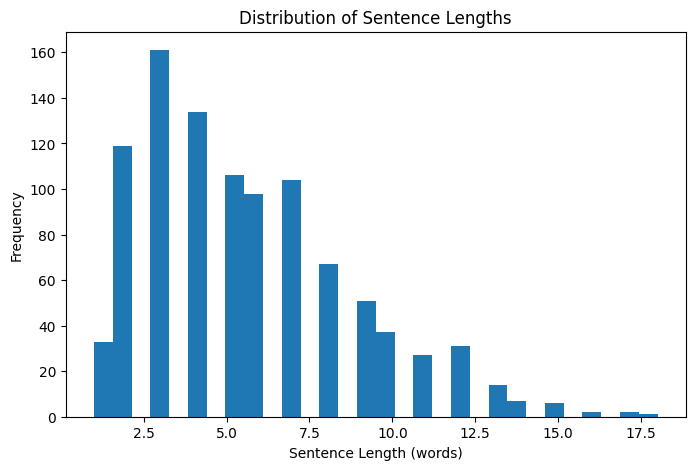

In [10]:
import matplotlib.pyplot as plt

sentence_lengths = df["sentence"].str.split().str.len()

plt.figure(figsize=(8,5))
plt.hist(sentence_lengths, bins=30)
plt.xlabel("Sentence Length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths")
plt.show()

In [11]:
from keras.preprocessing.sequence import pad_sequences

maxlen = 300  # Set the maximum length for padding

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen, truncating='post')
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen, truncating='post')

print(X_train[3, :])  

[114 376  44   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   

In [ ]:
# ---- Load pretrained Word2Vec embeddings via gensim ----
# Install once:  pip install gensim
# First run downloads ~1.6GB (Google News 300d). Cached afterwards.
# import gensim.downloader as api
# import numpy as np

# w2v = api.load('word2vec-google-news-300')
# print(f'Loaded {len(w2v.key_to_index)} Word2Vec vectors')

# embedding_dim = 300
# embedding_matrix = np.zeros((vocab_size, embedding_dim))
# for word, i in tokenizer.word_index.items():
#     if i >= vocab_size:
#         continue
#     if word in w2v:
#         embedding_matrix[i] = w2v[word]


In [250]:
import gensim.downloader as api
print(api.BASE_DIR)

C:\Users\I1000929/gensim-data


In [12]:
from gensim.models import KeyedVectors

path = r"C:\Users\I1000929\gensim-data\word2vec-google-news-300\word2vec-google-news-300.gz"

w2v = KeyedVectors.load_word2vec_format(
    path,
    binary=True
)

In [ ]:
import numpy as np

embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v:
        embedding_matrix[i] = w2v[word]

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.optimizers import Adam


# Build model
model = Sequential()

# Input layer
model.add(Input(shape=(maxlen,))) # time step

# Embedding layer (pretrained Word2Vec, frozen)
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
))

# Dropout on embeddings
model.add(Dropout(0.3))

# RNN layer with recurrent dropout
model.add(SimpleRNN(
    units=32,
    activation='tanh',
    dropout=0.3,
    recurrent_dropout=0.3
))

# Dropout
model.add(Dropout(0.5))

# Output layer (Binary Classification)
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Model summary
model.summary()

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 300)       │       502,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │        10,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513,489 (1.96 MB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 502,800 (1.92 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.5038 - loss: 0.7897 - val_accuracy: 0.4900 - val_loss: 0.6956
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5113 - loss: 0.7869 - val_accuracy: 0.5050 - val_loss: 0.6954
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4850 - loss: 0.7839 - val_accuracy: 0.4950 - val_loss: 0.6956
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5125 - loss: 0.7580 - val_accuracy: 0.4850 - val_loss: 0.6953
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5225 - loss: 0.7582 - val_accuracy: 0.4950 - val_loss: 0.6957
Restoring model weights from the end of the best epoch: 4.


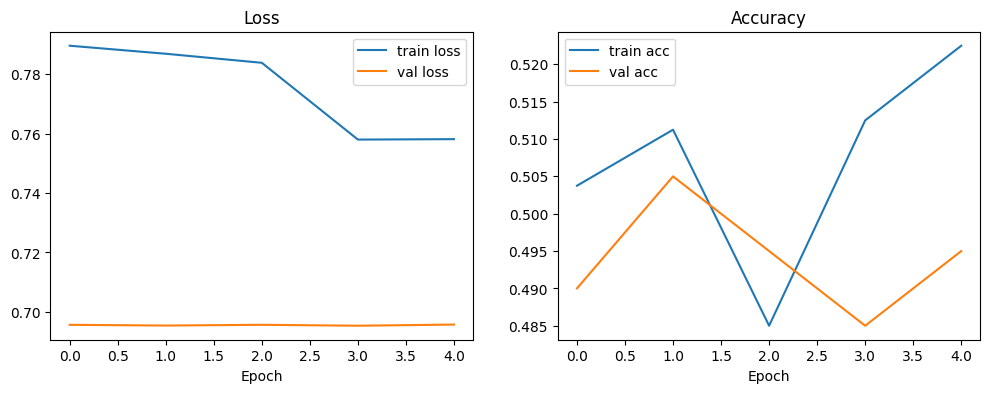

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='train loss')
ax[0].plot(history.history['val_loss'], label='val loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train acc')
ax[1].plot(history.history['val_accuracy'], label='val acc')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.show()

# Testing model on New input

In [18]:
import gradio as gr
import numpy as np

def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, padding='post', maxlen=maxlen)
    score = float(model.predict(np.array(seq))[0][0])
    label = 'Positive' if score >= 0.5 else 'Negative'
    return f"{label}"

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder='Type a review...'),
    outputs='text',
    title='Sentiment Analysis',
    examples=[
        ['did not like at all.'],
        ['nicest restaurant owners ive ever come across'],
        ['There is not a deal good enough that would drag me into that establishment again.']
    ]
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


# Why is SimpleRNN stuck near 51% accuracy?

1. **SimpleRNN can't handle long sequences** — vanishing gradients kick in after ~10-20 timesteps. With `maxlen=100`, Using **LSTM** instead usually jumps accuracy from ~50% to 75–85%.

2. **`num_words=500` is too small** — most vocabulary gets thrown away. Sentiment-carrying adjectives/adverbs fall outside the top 500 and their embeddings become zero vectors. Bump to 5000–10000.
